# 第4章: 言語解析

問題30から問題35までは、以下の文章`text`（太宰治の『走れメロス』の冒頭部分）に対して、言語解析を実施せよ。問題36から問題39までは、国家を説明した文書群（日本語版ウィキペディア記事から抽出したテキスト群）をコーパスとして、言語解析を実施せよ。

In [3]:
text = """
メロスは激怒した。
必ず、かの邪智暴虐の王を除かなければならぬと決意した。
メロスには政治がわからぬ。
メロスは、村の牧人である。
笛を吹き、羊と遊んで暮して来た。
けれども邪悪に対しては、人一倍に敏感であった。
"""

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 30. 動詞
文章`text`に含まれる動詞をすべて表示せよ。

In [3]:
!pip uninstall -y spacy ginza ja-ginza ja-ginza-electra

!pip install -U pip setuptools wheel
!pip install -U spacy ginza ja-ginza

Found existing installation: spacy 3.8.14
Uninstalling spacy-3.8.14:
  Successfully uninstalled spacy-3.8.14
Found existing installation: ginza 5.2.0
Uninstalling ginza-5.2.0:
  Successfully uninstalled ginza-5.2.0
Found existing installation: ja-ginza 5.2.0
Uninstalling ja-ginza-5.2.0:
  Successfully uninstalled ja-ginza-5.2.0
  Using cached ginza-5.2.0-py3-none-any.whl.metadata (448 bytes)
  Using cached ja_ginza-5.2.0-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.2/33.2 MB 82.4 MB/s  0:00:00
Using cached ginza-5.2.0-py3-none-any.whl (21 kB)
Using cached ja_ginza-5.2.0-py3-none-any.whl (59.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ja-ginza]


In [1]:
#mecabのインストール
!apt-get -q -y install mecab libmecab-dev mecab-ipadic-utf8
!pip install mecab-python3
!pip install unidic-lite

Reading package lists...
Building dependency tree...
Reading state information...
libmecab-dev is already the newest version (0.996-14build9).
mecab-ipadic-utf8 is already the newest version (2.7.0-20070801+main-3).
mecab is already the newest version (0.996-14build9).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [4]:
#spacyの結果。一部は誤り？
import spacy
config = {
    "components": {
        "compound_splitter": {
            "split_mode": "A",
        }
    }
}
nlp = spacy.load('ja_ginza', config = config)

doc = nlp(text)

verbs = [token.lemma_ for token in doc if token.pos_ == "VERB"]
print(verbs)

['激怒', '邪智', '除く', 'なる', '決意', 'わかる', 'ある', '吹く', '遊ぶ', '暮す', '来る', '対する', 'ある']


In [6]:
print(f"{'単語':<8} | {'品詞':<6} | {'係り受け（役割）'}")
print("-" * 35)

for token in doc:
    print(f"{token.text:<10} | {token.pos_:<8} | {token.dep_}")

単語       | 品詞     | 係り受け（役割）
-----------------------------------

          | NUM      | compound
メロス        | PROPN    | nsubj
は          | ADP      | case
激怒         | VERB     | ROOT
し          | AUX      | aux
た          | AUX      | aux
。          | PUNCT    | punct

          | ADV      | ROOT
必ず         | ADV      | advmod
、          | PUNCT    | punct
かの         | DET      | det
邪智         | VERB     | compound
暴虐         | NOUN     | nmod
の          | ADP      | case
王          | NOUN     | obj
を          | ADP      | case
除か         | VERB     | advcl
なけれ        | AUX      | aux
ば          | SCONJ    | fixed
なら         | VERB     | fixed
ぬ          | AUX      | fixed
と          | ADP      | case
決意         | VERB     | ROOT
し          | AUX      | aux
た          | AUX      | aux
。          | PUNCT    | punct

          | NUM      | compound
メロス        | PROPN    | obl
に          | ADP      | case
は          | ADP      | case
政治         | NOUN     | nsubj
が          | ADP     

In [7]:
import MeCab

tagger = MeCab.Tagger()
me_text = tagger.parse(text)
print(me_text)

メロス	メロス	メロス	メロス-melos	名詞-普通名詞-一般			1
は	ワ	ハ	は	助詞-係助詞			
激怒	ゲキド	ゲキド	激怒	名詞-普通名詞-サ変可能			1
し	シ	スル	為る	動詞-非自立可能	サ行変格	連用形-一般	0
た	タ	タ	た	助動詞	助動詞-タ	終止形-一般	
。			。	補助記号-句点			
必ず	カナラズ	カナラズ	必ず	副詞			0
、			、	補助記号-読点			
かの	カノ	カノ	彼の	連体詞			1
邪智	ジャチ	ジャチ	邪知	名詞-普通名詞-一般			1
暴虐	ボーギャク	ボウギャク	暴虐	名詞-普通名詞-形状詞可能			0
の	ノ	ノ	の	助詞-格助詞			
王	オー	オウ	王	名詞-普通名詞-一般			1
を	オ	ヲ	を	助詞-格助詞			
除か	ノゾカ	ノゾク	除く	動詞-一般	五段-カ行	未然形-一般	0
なけれ	ナケレ	ナイ	ない	助動詞	助動詞-ナイ	仮定形-一般	
ば	バ	バ	ば	助詞-接続助詞			
なら	ナラ	ナル	成る	動詞-非自立可能	五段-ラ行	未然形-一般	1
ぬ	ヌ	ズ	ず	助動詞	助動詞-ヌ	終止形-一般	
と	ト	ト	と	助詞-格助詞			
決意	ケツイ	ケツイ	決意	名詞-普通名詞-サ変可能			1,2
し	シ	スル	為る	動詞-非自立可能	サ行変格	連用形-一般	0
た	タ	タ	た	助動詞	助動詞-タ	終止形-一般	
。			。	補助記号-句点			
メロス	メロス	メロス	メロス-melos	名詞-普通名詞-一般			1
に	ニ	ニ	に	助詞-格助詞			
は	ワ	ハ	は	助詞-係助詞			
政治	セージ	セイジ	政治	名詞-普通名詞-一般			0
が	ガ	ガ	が	助詞-格助詞			
わから	ワカラ	ワカル	分かる	動詞-一般	五段-ラ行	未然形-一般	2
ぬ	ヌ	ズ	ず	助動詞	助動詞-ヌ	終止形-一般	
。			。	補助記号-句点			
メロス	メロス	メロス	メロス-melos	名詞-普通名詞-一般			1
は	ワ	ハ	は	助詞-係助詞			
、			、	補助記号-読点			
村	ムラ	ムラ	村	名詞-普通名詞-一般			2
の	ノ	ノ	の	助詞-格助詞			
牧人	ボクジン	ボクジン	牧人	名詞-普通名詞-一般			0
で	デ	ダ	だ	助動詞	助動詞-ダ	連用形-一般	
ある	ア

In [8]:
#mecabの結果
node = tagger.parseToNode(text)
while node:
  word = node.surface
  feature = node.feature.split(',')
  if feature[0] == '動詞':
    print(word)
  node = node.next

し
除か
なら
し
わから
ある
吹き
遊ん
暮し
来
対し
あっ


## 31. 動詞の原型
文章`text`に含まれる動詞と、その原型をすべて表示せよ。

In [9]:
node = tagger.parseToNode(text)
while node:
  word = node.surface
  feature = node.feature.split(',')
  if feature[0] == '動詞':
    print(word, feature[7])
  node = node.next

し 為る
除か 除く
なら 成る
し 為る
わから 分かる
ある 有る
吹き 吹く
遊ん 遊ぶ
暮し 暮らす
来 来る
対し 対する
あっ 有る


## 32. 「AのB」
文章`text`において、2つの名詞が「の」で連結されている名詞句をすべて抽出せよ。

In [10]:
node = tagger.parseToNode(text)
while node:

  word = node.surface
  feature = node.feature.split(',')

  if node.next is not None and node.next.next is not None:
    next_word = node.next.surface
    next_feature = node.next.feature.split(',')

    if next_feature[0] == '助詞' and next_word == "の":
      print(word, next_word, node.next.next.surface)
  node = node.next

暴虐 の 王
村 の 牧人


## 33. 係り受け解析

文章`text`に係り受け解析を適用し、係り元と係り先のトークン（形態素や文節などの単位）をタブ区切り形式ですべて抽出せよ。

In [5]:
import spacy
config = {
    "components": {
        "compound_splitter": {
            "split_mode": "A",
        }
    }
}
nlp = spacy.load("ja_ginza", config = config)

doc = nlp(text)

print(f"{'単語(係り元)':<10} | {'関係性':<10} | {'係り先'}")
print("-" * 40)

for token in doc:
    # token.text: 元の単語
    # token.dep_: 係り受けの関係（nsubj=主語, obj=目的語など）
    # token.head.text: 係り先の単語

    print(f"{token.text:<12} | {token.dep_:<10} | -> {token.head.text}")

単語(係り元)    | 関係性        | 係り先
----------------------------------------

            | compound   | -> メロス
メロス          | nsubj      | -> 激怒
は            | case       | -> メロス
激怒           | ROOT       | -> 激怒
し            | aux        | -> 激怒
た            | aux        | -> 激怒
。            | punct      | -> 激怒

            | ROOT       | -> 

必ず           | advmod     | -> 除か
、            | punct      | -> 必ず
かの           | det        | -> 暴虐
邪智           | compound   | -> 暴虐
暴虐           | nmod       | -> 王
の            | case       | -> 暴虐
王            | obj        | -> 除か
を            | case       | -> 王
除か           | advcl      | -> 決意
なけれ          | aux        | -> 除か
ば            | fixed      | -> なけれ
なら           | fixed      | -> なけれ
ぬ            | fixed      | -> なけれ
と            | case       | -> 除か
決意           | ROOT       | -> 決意
し            | aux        | -> 決意
た            | aux        | -> 決意
。            | punct      | -> 決意

            | compound   | -> メロス
メロス     

## 34. 主述の関係
文章`text`において、「メロス」が主語であるときの述語を抽出せよ。

In [8]:
import spacy

nlp = spacy.load("ja_ginza", config = config)

doc = nlp(text)

for token in doc:
    if token.dep_ == "nsubj" and token.text == "メロス":
        print(token.head.lemma_)

激怒
牧人


## 35. 係り受け木
「メロスは激怒した。」の係り受け木を可視化せよ。

In [12]:
import spacy
from spacy import displacy

nlp = spacy.load("ja_ginza", config = config)

doc = nlp("メロスは激怒した")

displacy.render(doc, style = "dep", jupyter = True)

## 36. 単語の出現頻度

問題36から39までは、Wikipediaの記事を以下のフォーマットで書き出したファイル[jawiki-country.json.gz](/data/jawiki-country.json.gz)をコーパスと見なし、統計的な分析を行う。

* 1行に1記事の情報がJSON形式で格納される
* 各行には記事名が"title"キーに、記事本文が"text"キーの辞書オブジェクトに格納され、そのオブジェクトがJSON形式で書き出される
* ファイル全体はgzipで圧縮される

まず、第3章の処理内容を参考に、Wikipedia記事からマークアップを除去し、各記事のテキストを抽出せよ。そして、コーパスにおける単語（形態素）の出現頻度を求め、出現頻度の高い20語とその出現頻度を表示せよ。

In [19]:
import re

In [20]:
def remove_emphasis_markup(text):
  # 最も長いマークアップから順に置換
  text = re.sub(r"'''''", "", text) # 5つのシングルクォート (太字斜体)
  text = re.sub(r"'''", "", text)  # 3つのシングルクォート (太字)
  text = re.sub(r"''", "", text)   # 2つのシングルクォート (斜体)
  return text


In [21]:
def remove_internal_links(text):
  # [[記事名]] または [[記事名|表示文字]]、[[:en:記事名]]、[[:en:記事名|表示文字]]など
  # (?:[^:\]\|]*?:)? : オプションのインターウィキリンク（例: :en:）
  # (?:[^\|\]]*?\|)? : オプションのリンク先記事名（例: スターリング・ポンド|）
  # ([^\|\]]+?) : 表示文字（または記事名）
  text = re.sub(r"\[\[(?:[^:\]\|]*?:)?(?:[^\|\]]*?\|)?([^\|\]]+?)\]\]", r"\1", text)
  return text

In [22]:
def remove_mediawiki_markups(text):
  # <ref>...</ref> と <ref name="...">...</ref> を除去
  text = re.sub(r"<ref[^>]*?>.*?</ref>", "", text)
  text = re.sub(r"<ref[^>]*?/>", "", text)
  # {{...}}を除去
  while True:
      # 外側の最も内側の {{...}} を見つけて除去
      new_text = re.sub(r"\{\{[^\{\}]*?\}\}", "", text)
      if new_text == text:
          break
      text = new_text
  # <br /> などのHTMLタグを除去
  text = re.sub(r"<br\s*/>", "", text)
  text = re.sub(r"<[^>]*>", "", text) # 他のHTMLタグも除去
  return text

In [38]:
import gzip
import json
import MeCab
from collections import Counter

file = "/content/drive/MyDrive/jawiki-country.json.gz"

all_texts = []
with gzip.open(file, "rt", encoding="utf-8") as f:
  articles = []
  for line in f:
    article_data = json.loads(line)
    text = article_data["text"]
    text = remove_emphasis_markup(text)
    text = remove_internal_links(text)
    text = remove_mediawiki_markups(text)
    all_texts.append(text)
    articles.append(json.loads(line))

tag_parser = MeCab.Tagger()

word_counts = Counter()

for article_text in all_texts:
  node = tag_parser.parseToNode(article_text)
  while node:
    word = node.surface
    feature = node.feature.split(',')
    if word.strip() and node.posid != 0 and feature[0] != '補助記号':
      word_counts[word] += 1
    node = node.next

# 出現頻度の高い20語を表示
print("出現頻度の高い20語:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

出現頻度の高い20語:
の: 85381
に: 60306
は: 50008
が: 42503
を: 36991
て: 34858
た: 34507
で: 33232
と: 32836
し: 29076
年: 23392
れ: 13452
いる: 13013
さ: 12174
ある: 11387
も: 10694
する: 9198
月: 9162
人: 8853
から: 8327


## 37. 名詞の出現頻度
コーパスにおける名詞の出現頻度を求め、出現頻度の高い20語とその出現頻度を表示せよ。

In [33]:
import MeCab
from collections import Counter

tag_parser = MeCab.Tagger()

noun_counts = Counter()

for article_text in all_texts:
  node = tag_parser.parseToNode(article_text)
  while node:
    word = node.surface
    feature = node.feature.split(',')
    # 品詞が「名詞」である場合にカウント
    if feature[0] == '名詞':
      noun_counts[word] += 1
    node = node.next

# 出現頻度の高い20の名詞を表示
print("出現頻度の高い20の名詞:")
for word, count in noun_counts.most_common(20):
    print(f"{word}: {count}")

出現頻度の高い20の名詞:
年: 23392
月: 9162
語: 5576
1: 5435
日本: 4663
こと: 4429
2: 4167
3: 3610
世界: 3499
政府: 3288
大統領: 3178
共和: 3174
5: 3050
thumb: 3012
ため: 3010
4: 2880
州: 2647
経済: 2608
万: 2517
アメリカ: 2453


## 38. TF・IDF
日本に関する記事における名詞のTF・IDFスコアを求め、TF・IDFスコア上位20語とそのTF, IDF, TF・IDFを表示せよ。

In [45]:
import MeCab
from collections import Counter
import math

tag_parser = MeCab.Tagger()

noun_counts = Counter()
total_counts = 0
#記事数
counts = 0
df_counts = Counter()
nouns = []
data = None
for article in articles:
  counts += 1
  if article.get("title") == "日本":
    data = article
    for line in data["text"].split("\n"):
      node = tag_parser.parseToNode(line)
      while node:
        word = node.surface
        feature = node.feature.split(',')
        if feature[0] == '名詞':
          nouns.append(word)
          noun_counts[word] += 1
          total_counts += 1
        node = node.next
df_noun_counts = Counter()
for article_text in all_texts:
  seen_in_article = set()
  node = tag_parser.parseToNode(article_text)
  while node:
    word = node.surface
    feature = node.feature.split(',')
    if feature[0] == '名詞':
      seen_in_article.add(word)
    node = node.next
  for word in seen_in_article:
    df_noun_counts[word] += 1


num_articles = len(all_texts)

result = []

for word, count in noun_counts.items():
  tf = count / total_counts
  idf = math.log(num_articles / (df_noun_counts[word] + 1))
  tf_idf = tf * idf
  result.append((word, tf, idf, tf_idf))

result.sort(key=lambda x: x[3], reverse=True)

print("【記事「日本」のTF-IDF スコア トップ20】")
print(f"{'単語':<15} | {'TF':<8} | {'IDF':<7} | {'TF-IDF':5}")
print("-" * 65)

for word, tf, idf, tfidf in result[:20]:
    print(f"{word:<15} | {tf:.5f} | {idf:.5f} | {tfidf:.5f}")

【記事「日本」のTF-IDF スコア トップ20】
単語              | TF       | IDF     | TF-IDF
-----------------------------------------------------------------
ref             | 0.01928 | 5.51343 | 0.10632
div             | 0.00374 | 5.51343 | 0.02061
url             | 0.00308 | 4.82028 | 0.01483
Cite            | 0.00263 | 5.51343 | 0.01448
title           | 0.00312 | 4.41482 | 0.01379
accessdate      | 0.00248 | 4.82028 | 0.01198
E               | 0.00662 | 1.68479 | 0.01116
name            | 0.00187 | 4.82028 | 0.00901
web             | 0.00459 | 1.95808 | 0.00899
頁               | 0.00140 | 5.51343 | 0.00770
publisher       | 0.00159 | 4.82028 | 0.00764
pt              | 0.00194 | 3.56752 | 0.00692
ff              | 0.00109 | 5.51343 | 0.00600
天皇              | 0.00218 | 2.74084 | 0.00597
archiveurl      | 0.00102 | 5.51343 | 0.00561
archivedate     | 0.00102 | 5.51343 | 0.00561
height          | 0.00173 | 3.21084 | 0.00555
Times           | 0.00111 | 4.82028 | 0.00536
deadlinkdate    | 0.00097 | 5.5134

## 39. Zipfの法則
コーパスにおける単語の出現頻度順位を横軸、その出現頻度を縦軸として、両対数グラフをプロットせよ。

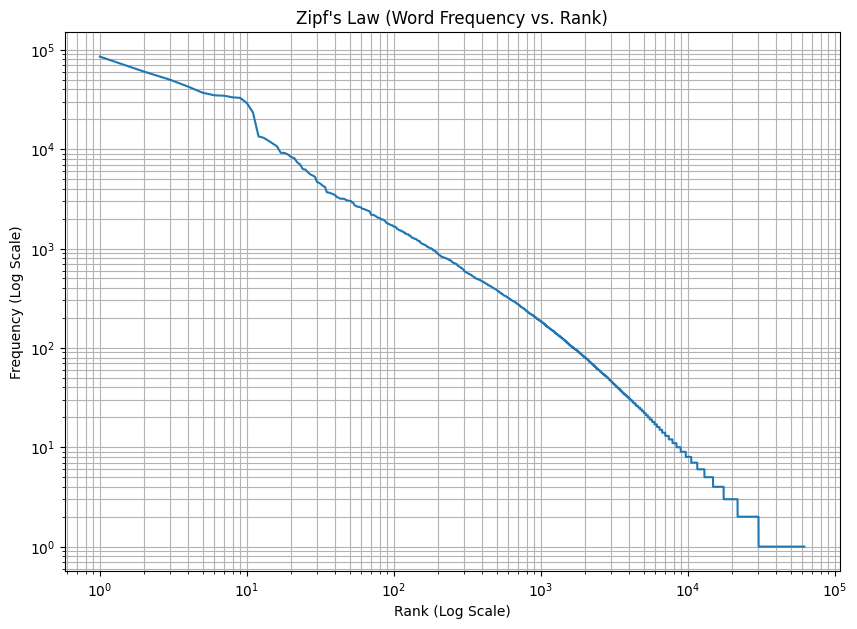

In [47]:
import matplotlib.pyplot as plt

freq_list = sorted(word_counts.values(), reverse=True)

ranks = range(1, len(freq_list) + 1)
frequencies = freq_list

plt.figure(figsize=(10, 7))
plt.loglog(ranks, frequencies, linestyle='-', marker='None')

plt.title('Zipf\'s Law (Word Frequency vs. Rank)')
plt.xlabel('Rank (Log Scale)')
plt.ylabel('Frequency (Log Scale)')
plt.grid(True, which="both", ls="-", color='0.7')
plt.show()